## Importing Libraries

In [3]:
import tensorflow as tf 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

## Data Perprossing

### Training Image Preprocessing

In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 140590 files belonging to 38 classes.


### Validation Image Preprocessing 

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
)

Found 35144 files belonging to 38 classes.


In [7]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set: 
    print(x,x.shape) 
    print(y,y.shape) 
    break

tf.Tensor(
[[[[113.5  103.5  101.5 ]
   [113.   103.   101.  ]
   [109.5   99.5   97.5 ]
   ...
   [ 98.    86.    86.  ]
   [109.    97.    97.  ]
   [107.    95.    95.  ]]

  [[109.5   99.5   97.5 ]
   [108.5   98.5   96.5 ]
   [107.5   97.5   95.5 ]
   ...
   [108.5   96.5   96.5 ]
   [104.5   92.5   92.5 ]
   [100.    88.    88.  ]]

  [[111.25 101.25  99.25]
   [115.   105.   103.  ]
   [114.75 104.75 102.75]
   ...
   [109.75  97.75  97.75]
   [109.75  97.75  97.75]
   [103.25  91.25  91.25]]

  ...

  [[156.75 150.75 152.75]
   [164.75 158.75 160.75]
   [153.   147.   149.  ]
   ...
   [147.75 141.75 143.75]
   [149.25 143.25 145.25]
   [152.75 146.75 148.75]]

  [[161.75 155.75 157.75]
   [152.75 146.75 148.75]
   [152.75 146.75 148.75]
   ...
   [150.   144.   146.  ]
   [150.75 144.75 146.75]
   [150.75 144.75 146.75]]

  [[154.5  148.5  150.5 ]
   [167.5  161.5  163.5 ]
   [161.25 155.25 157.25]
   ...
   [158.5  152.5  154.5 ]
   [151.75 145.75 147.75]
   [159.25 153.25 15

## Building Model

In [84]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [85]:
model = Sequential()

In [86]:
## Building Convolution Layer

In [87]:
model.add(Conv2D(filters=32, kernel_size=3,padding='same', activation='relu', input_shape=[128,128,3])) 
model.add(Conv2D(filters=32, kernel_size=3, activation='relu')) 
model.add (MaxPool2D(pool_size=2,strides=2))

In [88]:
model.add(Conv2D(filters=64, kernel_size=3,padding='same', activation='relu')) 
model.add(Conv2D(filters=64, kernel_size=3, activation='relu')) 
model.add (MaxPool2D(pool_size=2,strides=2))

In [89]:
model.add(Conv2D(filters=128, kernel_size=3,padding='same', activation='relu')) 
model.add(Conv2D(filters=128, kernel_size=3, activation='relu')) 
model.add (MaxPool2D(pool_size=2,strides=2))

In [90]:
model.add(Conv2D(filters=256, kernel_size=3,padding='same', activation='relu')) 
model.add(Conv2D(filters=256, kernel_size=3, activation='relu')) 
model.add (MaxPool2D(pool_size=2,strides=2))

In [91]:
model.add(Conv2D(filters=512, kernel_size=3,padding='same', activation='relu')) 
model.add(Conv2D(filters=512, kernel_size=3,activation='relu')) 
model.add (MaxPool2D(pool_size=2,strides=2))

In [92]:
model.add (Dropout (0.25))

In [93]:
model.add(Flatten())

In [94]:
model.add(Dense(units=1500, activation='relu'))

In [95]:
model.add (Dropout (0.4))

In [96]:
##Output Layer 
model.add (Dense(units=38, activation='softmax'))

### Compiling Model

In [120]:
model.compile(optimizer=tf.keras.optimizers.Adam( 
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [121]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_57 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training 

In [99]:
training_history = model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 3875s 881ms/step - accuracy: 0.5247 - loss: 1.6575 - val_accuracy: 0.9001 - val_loss: 0.3070
Epoch 2/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 2470s 562ms/step - accuracy: 0.9107 - loss: 0.2777 - val_accuracy: 0.9374 - val_loss: 0.1980
Epoch 3/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 1890s 430ms/step - accuracy: 0.9528 - loss: 0.1448 - val_accuracy: 0.9436 - val_loss: 0.1855
Epoch 4/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 1721s 392ms/step - accuracy: 0.9694 - loss: 0.0921 - val_accuracy: 0.9487 - val_loss: 0.1697
Epoch 5/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 2451s 558ms/step - accuracy: 0.9774 - loss: 0.0696 - val_accuracy: 0.9697 - val_loss: 0.1047
Epoch 6/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 2475s 563ms/step - accuracy: 0.9844 - loss: 0.0492 - val_accuracy: 0.9723 - val_loss: 0.0961
Epoch 7/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 2416s 550ms/step - accuracy: 0.9861 - loss: 0.0439 - val_accuracy: 0.9781 - val_loss: 0.0784
Epoch 8/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 1724s 392ms/s

### Model Evaluation 

In [103]:
train_loss, train_acc = model.evaluate(training_set)

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 676s 154ms/step - accuracy: 0.9948 - loss: 0.0173 


In [104]:
print(train_loss, train_acc)

0.016149917617440224 0.9952059388160706


In [101]:
val_loss,val_acc = model.evaluate(validation_set)

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 168s 153ms/step - accuracy: 0.9704 - loss: 0.1098


In [105]:
print(val_loss, val_acc)

0.10574992001056671 0.970805823802948


### Saving Model

In [122]:
model.save("trained_model.keras")

In [123]:
training_history.history

{'accuracy': [0.7200156450271606,
  0.92607581615448,
  0.9582473635673523,
  0.972579836845398,
  0.9799772500991821,
  0.984465479850769,
  0.987253725528717,
  0.9886478185653687,
  0.9901273250579834,
  0.990696370601654],
 'loss': [0.9334079623222351,
  0.23053967952728271,
  0.12693509459495544,
  0.0826190784573555,
  0.0625830590724945,
  0.04816419258713722,
  0.04044003784656525,
  0.03586668148636818,
  0.031720176339149475,
  0.029270479455590248],
 'val_accuracy': [0.9001252055168152,
  0.9374004006385803,
  0.9436034560203552,
  0.9487252235412598,
  0.9697245359420776,
  0.9723423719406128,
  0.978147029876709,
  0.9738219976425171,
  0.9758138060569763,
  0.970805823802948],
 'val_loss': [0.3070209324359894,
  0.19801045954227448,
  0.18553994596004486,
  0.1696932017803192,
  0.10465880483388901,
  0.09614972770214081,
  0.07841762900352478,
  0.09473001956939697,
  0.09873028844594955,
  0.10574982315301895]}

In [124]:
import json
with open("training_hist.json", "w") as f: 
    json.dump(training_history.history,f)

In [125]:
training_history.history['accuracy']

[0.7200156450271606,
 0.92607581615448,
 0.9582473635673523,
 0.972579836845398,
 0.9799772500991821,
 0.984465479850769,
 0.987253725528717,
 0.9886478185653687,
 0.9901273250579834,
 0.990696370601654]

In [127]:
training_history.history['val_accuracy']

[0.9001252055168152,
 0.9374004006385803,
 0.9436034560203552,
 0.9487252235412598,
 0.9697245359420776,
 0.9723423719406128,
 0.978147029876709,
 0.9738219976425171,
 0.9758138060569763,
 0.970805823802948]

### Accuracy Visualisation 

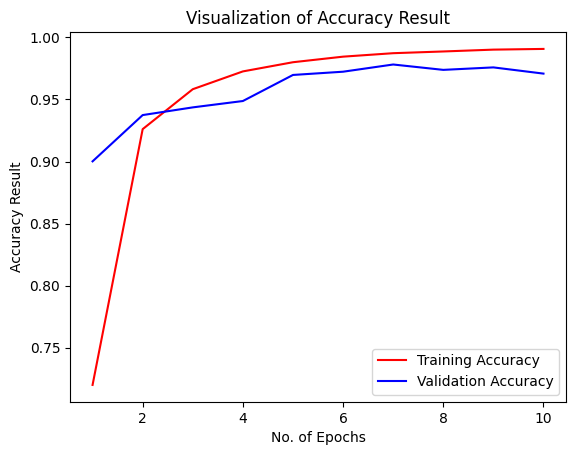

In [130]:
epochs = [i for i in range(1,11)] 
plt.plot(epochs, training_history.history['accuracy'], color='red',label='Training Accuracy') 
plt.plot(epochs, training_history.history['val_accuracy'], color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs") 
plt.ylabel("Accuracy Result") 
plt.title("Visualization of Accuracy Result")
plt. legend()
plt.show()

### Some Other Matrices For Model Evalution 

In [131]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [132]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 35144 files belonging to 38 classes.


In [133]:
y_pred = model.predict(test_set) 
y_pred,y_pred.shape

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 173s 157ms/step


(array([[1.0000000e+00, 1.4680032e-12, 8.7309576e-13, ..., 4.1489835e-22,
         7.4201093e-20, 1.1153966e-17],
        [1.0000000e+00, 1.4680032e-12, 8.7309576e-13, ..., 4.1489835e-22,
         7.4201093e-20, 1.1153966e-17],
        [1.0000000e+00, 7.2723013e-13, 4.1047673e-12, ..., 6.4196279e-22,
         1.3467602e-17, 3.7002988e-17],
        ...,
        [4.8866536e-11, 7.6398882e-14, 8.2094165e-11, ..., 6.4551676e-12,
         4.3589614e-13, 9.9999988e-01],
        [3.4967675e-22, 7.6716526e-24, 8.5217439e-21, ..., 6.1918950e-25,
         5.1425811e-21, 1.0000000e+00],
        [3.4967675e-22, 7.6716526e-24, 8.5217439e-21, ..., 6.1918950e-25,
         5.1425811e-21, 1.0000000e+00]], dtype=float32),
 (35144, 38))

In [134]:
predicted_categories = tf.argmax(y_pred, axis=1)

In [135]:
predicted_categories

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [137]:
true_categories = tf.concat([y for x,y in test_set], axis=0) 
true_categories

<tf.Tensor: shape=(35144, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [140]:
Y_true = tf.argmax(true_categories, axis=1) 
Y_true

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

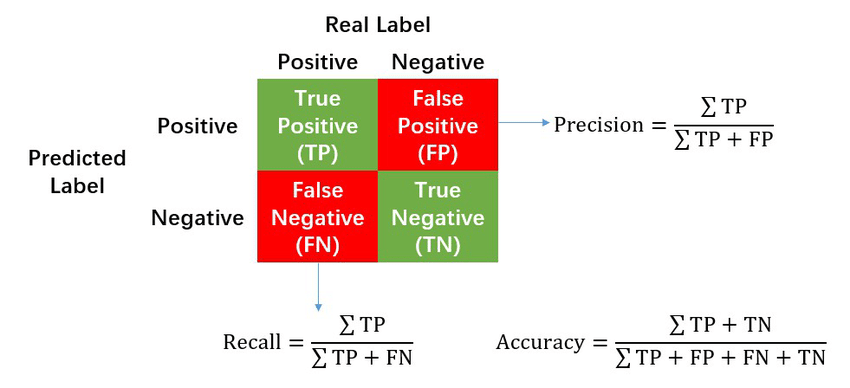

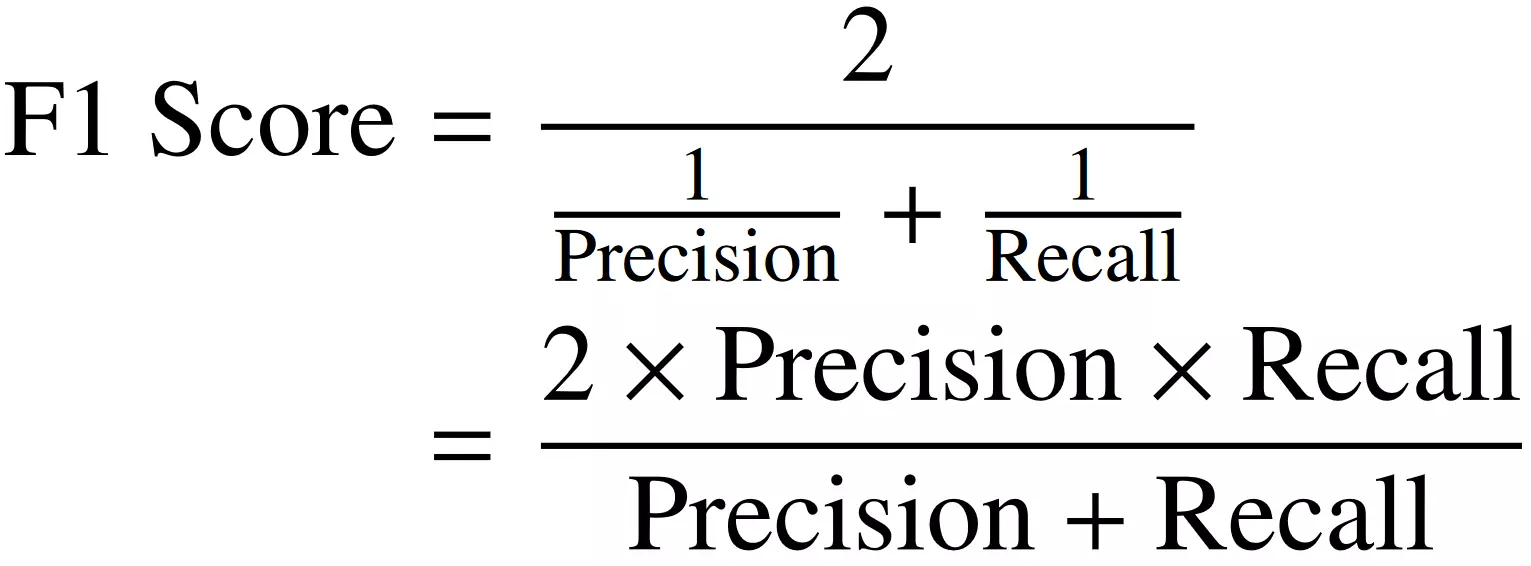

In [144]:
from sklearn.metrics import classification_report,confusion_matrix

In [143]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.99      0.97      1008
                                 Apple___Black_rot       0.98      0.99      0.99       994
                          Apple___Cedar_apple_rust       0.96      1.00      0.98       880
                                   Apple___healthy       0.99      0.96      0.97      1004
                               Blueberry___healthy       0.99      0.98      0.98       908
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      0.99       842
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       912
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.96      0.94       820
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       954
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.94      0.

In [147]:
cm = confusion_matrix(Y_true, predicted_categories)  
cm

array([[1000,    2,    0, ...,    0,    0,    0],
       [   0,  986,    2, ...,    0,    0,    0],
       [   0,    0,  878, ...,    0,    0,    0],
       ...,
       [   0,    0,    4, ...,  950,    0,    0],
       [   0,    0,    0, ...,    0,  882,    0],
       [   0,    0,    2, ...,    0,    0,  958]])

### Confusion Matrix Visualization 

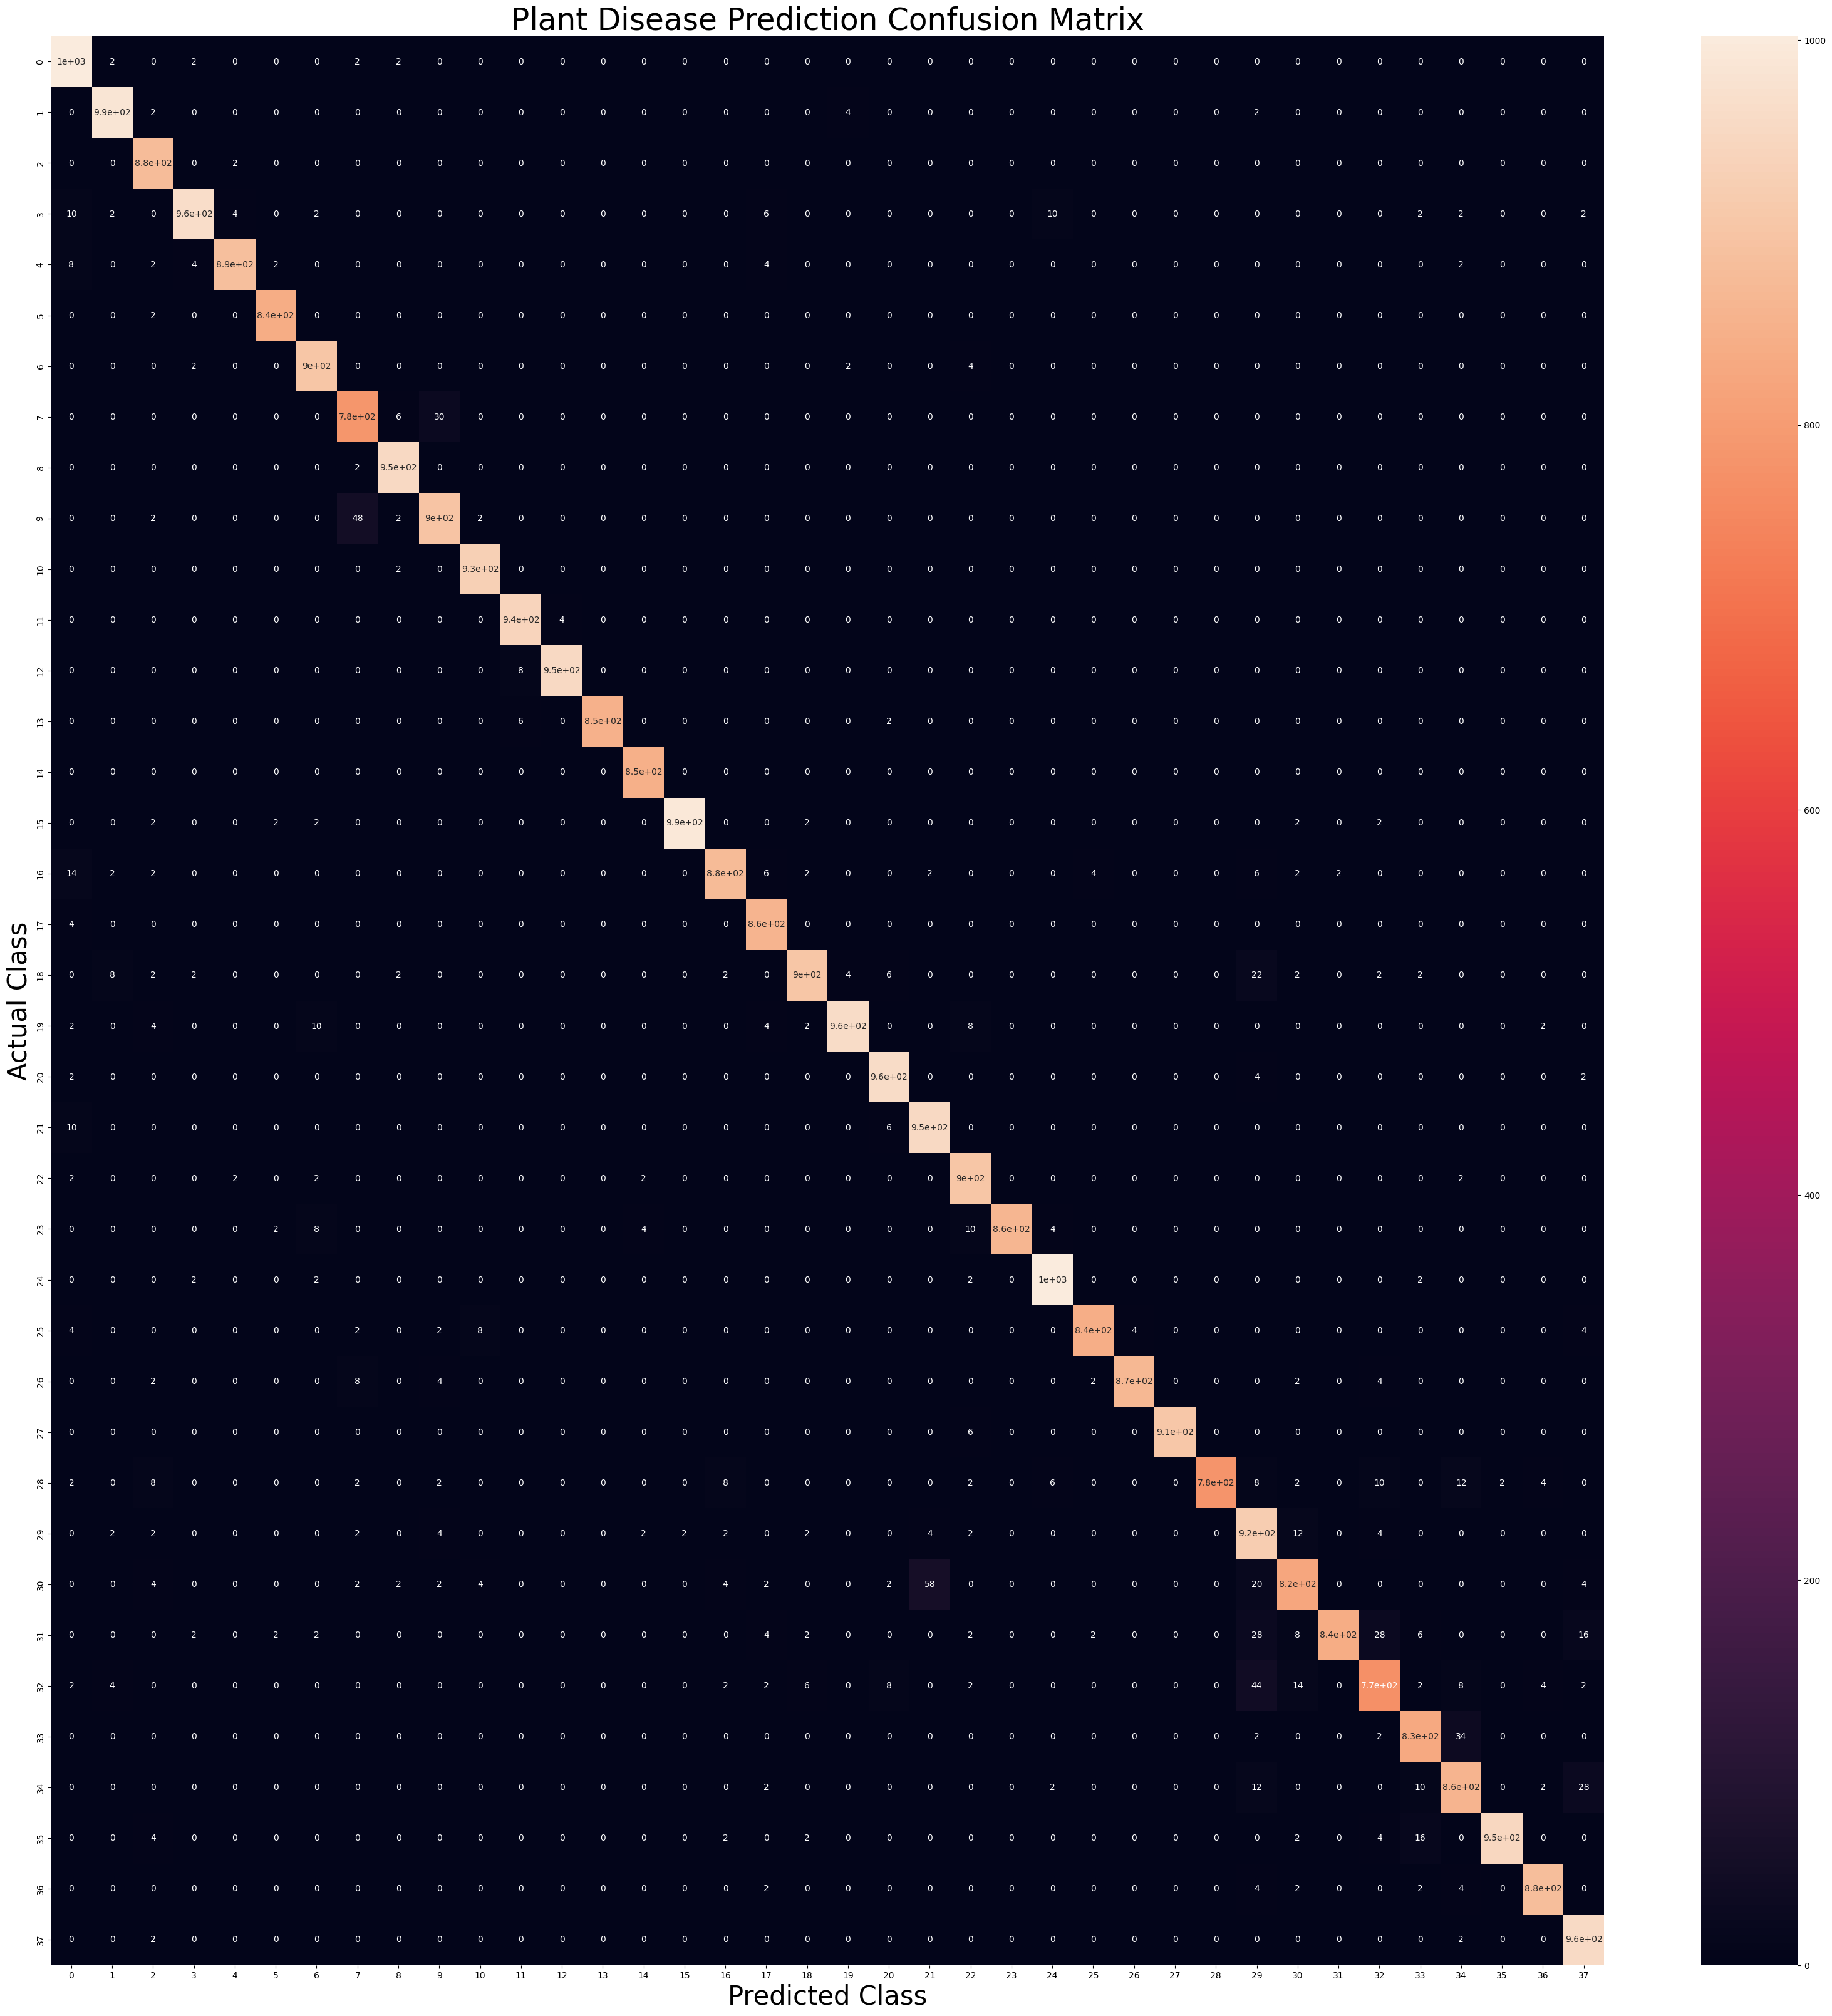

In [156]:
plt.figure (figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class", fontsize=30)
plt.ylabel("Actual Class", fontsize=30)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=35)
plt.show()